In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
csv_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"

df = pd.read_csv(csv_path, sep=';')

df.head()

,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp,next_cluster,cluster
0,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,89,1,2.940217,0.279338,5.909524,0.066667,0.000749,15.0,8
1,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,SM,89,1,2.940217,0.095890,5.909524,0.066667,0.000749,19.0,15
2,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,SM,89,1,2.940217,0.271233,5.909524,0.066667,0.000749,19.0,19
3,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,WM,89,1,2.940217,0.076712,5.909524,0.066667,0.000749,8.0,19
4,100431_1,BLSC,W,W1,2,M,ASY,Southern New England,Rhode Island,-70.839910,...,WM,89,1,2.940217,0.010959,5.909524,0.066667,0.000749,7.0,8


   Progresso: 5/28 nodi...
   Progresso: 10/28 nodi...
   Progresso: 15/28 nodi...
   Progresso: 20/28 nodi...
   Progresso: 25/28 nodi...


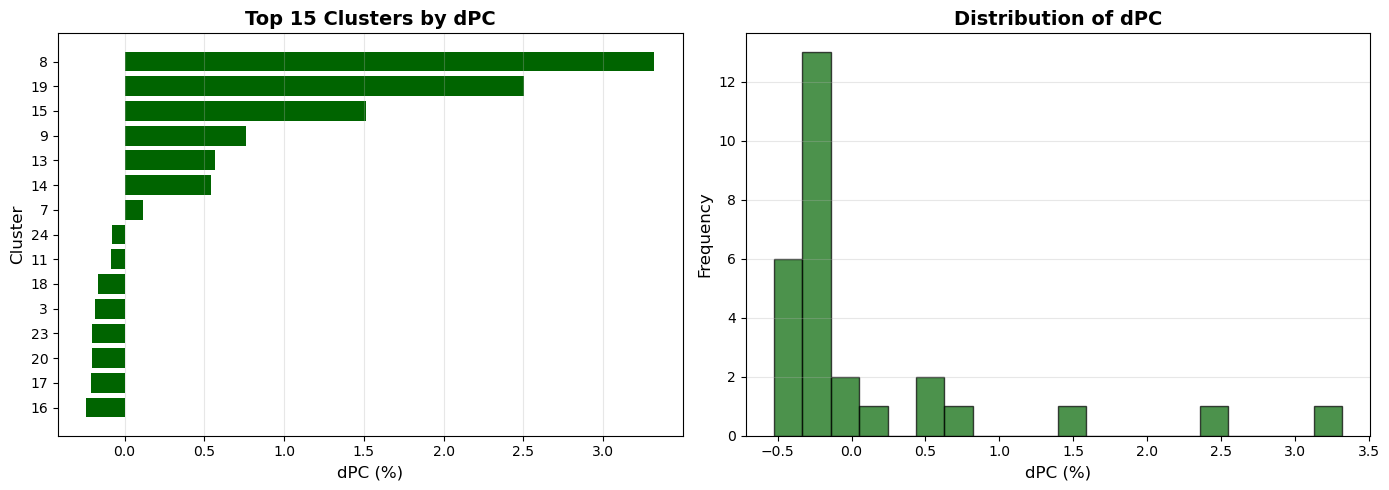

In [8]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def calculate_dPC(df, alpha=0.5):

    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)

    node_weights = df.groupby('cluster')['wt_sp'].sum().to_dict()
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']

    G = nx.DiGraph()
    
    for node, weight in node_weights.items():
        G.add_node(node, weight=weight)

    for _, row in edge_weights.iterrows():
        weight = row['weight']
        distance = 1.0 / (weight ** alpha)  
        G.add_edge(int(row['source']), int(row['target']), 
                   weight=weight, distance=distance)

    PC_total = calculate_PC(G, alpha)
    
    dpc_results = []
    nodes = list(G.nodes())
    
    for i, node in enumerate(nodes):
        if (i + 1) % 5 == 0:
            print(f"   Progresso: {i+1}/{len(nodes)} nodi...")
        
        G_without_k = G.copy()
        G_without_k.remove_node(node)
    
        PC_without_k = calculate_PC(G_without_k, alpha)
        
        if PC_total > 0:
            dPC = ((PC_total - PC_without_k)/PC_total) * 100
        else:
            dPC = 0
        
        dpc_results.append({
            'cluster': node,
            'dPC': dPC,
            'PC_without': PC_without_k
        })
    
    dpc_df = pd.DataFrame(dpc_results).sort_values('dPC', ascending=False)
    
    
    return dpc_df, G


def calculate_PC(G, alpha):

    
    if G.number_of_nodes() == 0:
        return 0.0

    nodes = list(G.nodes())
    node_weights = {node: G.nodes[node].get('weight', 1) for node in nodes}
    
    A_L = sum(node_weights.values())
    
    if A_L == 0:
        return 0.0
    
    
    try:
        all_paths = dict(nx.all_pairs_dijkstra_path_length(G, weight='distance'))
    except:
        all_paths = {}
    
    PC = 0.0
    
    for i in nodes:
        for j in nodes:
            if i == j:
            
                p_ij_star = 1.0
            else:
            
                if i in all_paths and j in all_paths[i]:
                    
                    dist_ij = all_paths[i][j]
                    
                    p_ij_star = np.exp(-dist_ij)
                else:
                    
                    p_ij_star = 0.0
           
            a_i = node_weights[i]
            a_j = node_weights[j]
            PC += a_i * a_j * p_ij_star
  
    PC = PC / (A_L ** 2)
    
    return PC


def plot_dPC_results(dpc_df):
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Top 15 cluster per dPC
    ax1 = axes[0]
    top_dpc = dpc_df.head(15)
    ax1.barh(top_dpc['cluster'].astype(str), top_dpc['dPC'], color='darkgreen')
    ax1.set_xlabel('dPC (%)', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by dPC', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Distribuzione dPC
    ax2 = axes[1]
    ax2.hist(dpc_df['dPC'], bins=20, edgecolor='black', alpha=0.7, color='darkgreen')
    ax2.set_xlabel('dPC (%)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of dPC', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Calcola dPC
dpc_df, G = calculate_dPC(df, alpha=0.5)

# Plot risultati
plot_dPC_results(dpc_df)


📊 Range dPC: -0.53% to 5.00%
   Negativi: 21 cluster
   Positivi: 7 cluster


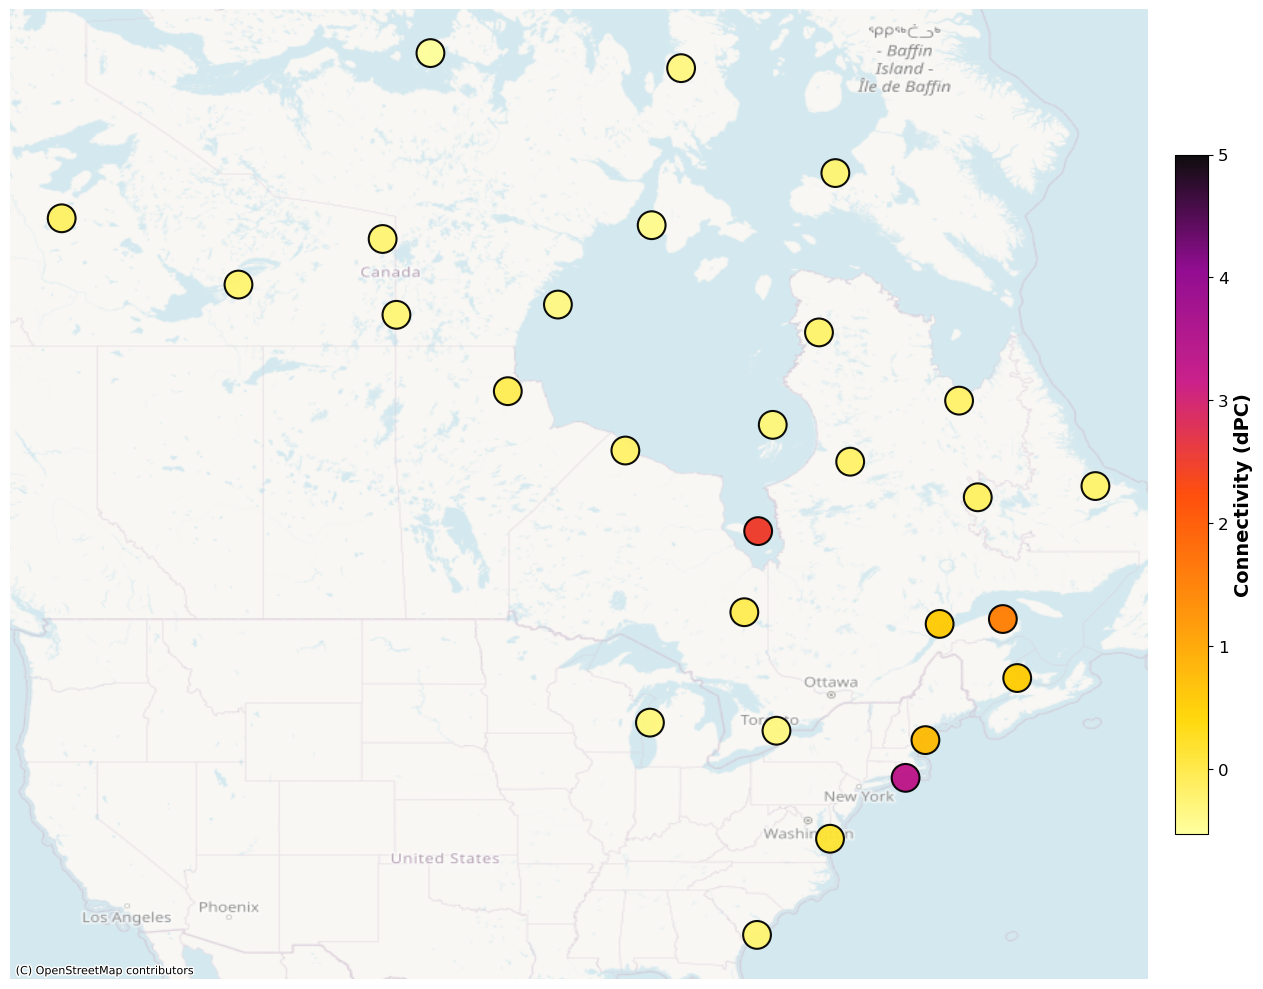

In [9]:
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def plot_dPC_map(df, dpc_df):
   
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(dpc_df, on='cluster')
    
    def lat_lon_to_web_mercator(lon, lat):
        x = lon * 20037508.34 / 180
        y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
        y = y * 20037508.34 / 180
        return x, y
    
    x_coords = []
    y_coords = []
    for _, row in cluster_data.iterrows():
        x, y = lat_lon_to_web_mercator(row['lon'], row['lat'])
        x_coords.append(x)
        y_coords.append(y)
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    colors = ['#FFFF99', '#FFD700', '#FF8C00', '#FF4500', '#C71585', '#8B008B', '#000000']
    cmap = LinearSegmentedColormap.from_list('dpc', colors, N=256)
  
    dpc_percent = cluster_data['dPC']
    
   
    vmin = min(0, dpc_percent.min())  
    vmax = max(5, dpc_percent.max())   
    
    print(f"\n📊 Range dPC: {vmin:.2f}% to {vmax:.2f}%")
    print(f"   Negativi: {(dpc_percent < 0).sum()} cluster")
    print(f"   Positivi: {(dpc_percent >= 0).sum()} cluster")
    

    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=dpc_percent,
        s=400,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.95
    )
    
   
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
        
    ax.set_facecolor('#E8F4F8')
    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    cbar.set_label('Connectivity (dPC)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    
plot_dPC_map(df, dpc_df)

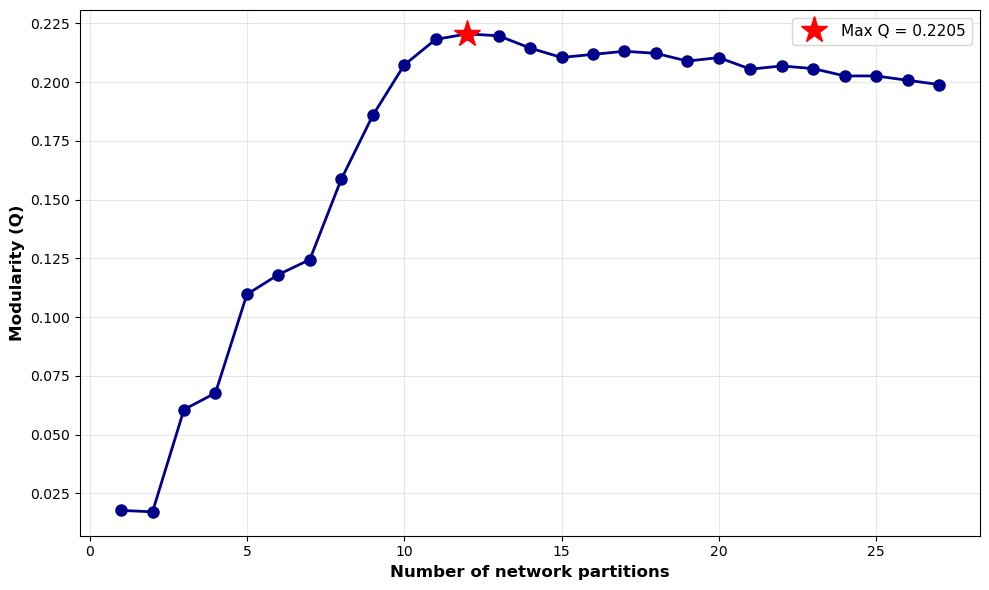

In [14]:
import pandas as pd
import networkx as nx
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity
import matplotlib.pyplot as plt
import numpy as np

def calculate_modularity_girvan_newman_weighted(df, alpha=0.5):

    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']
  
    G_directed = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        weight = row['weight']
        weight_alpha = weight ** alpha
      
        distance = 1.0 / weight_alpha
        G_directed.add_edge(
            int(row['source']), 
            int(row['target']), 
            weight=weight_alpha,
            distance=distance
        )

    G = G_directed.to_undirected()
    
    #Trova l'arco con edge betweenness più alta
    def most_valuable_edge_weighted(graph):

        betweenness = nx.edge_betweenness_centrality(graph, weight='distance')
        return max(betweenness, key=betweenness.get)
    
    communities_generator = girvan_newman(G, most_valuable_edge=most_valuable_edge_weighted)
  
    all_modularities = []
    all_communities = []
    
    best_modularity = -1
    best_communities = None
    
    max_iterations = G.number_of_nodes() - 1
    
    for i, communities in enumerate(communities_generator):
        if i >= max_iterations:
            break
        
        communities_list = [set(c) for c in communities]
        
        Q = modularity(G, communities_list, weight='weight')
        
        all_modularities.append(Q)
        all_communities.append(communities_list)
        
        if Q > best_modularity:
            best_modularity = Q
            best_communities = communities_list
    
    for i, community in enumerate(sorted(best_communities, key=len, reverse=True), 1):
        clusters = sorted(list(community))
    
    return best_communities, best_modularity, G, all_modularities, all_communities


def plot_modularity_results(all_modularities, title_suffix=""):

    fig, ax = plt.subplots(figsize=(10, 6))
    
    iterations = range(1, len(all_modularities) + 1)
    ax.plot(iterations, all_modularities, 'o-', linewidth=2, markersize=8, color='darkblue')

    max_idx = np.argmax(all_modularities)
    max_Q = all_modularities[max_idx]
    ax.plot(max_idx + 1, max_Q, 'r*', markersize=20, label=f'Max Q = {max_Q:.4f}')
    
    ax.set_xlabel('Number of network partitions', fontsize=12, fontweight='bold')
    ax.set_ylabel('Modularity (Q)', fontsize=12, fontweight='bold')
  
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()


def assign_communities_to_clusters(best_communities):
  
    community_assignment = []
    
    for comm_id, community in enumerate(best_communities, 1):
        for cluster in community:
            community_assignment.append({
                'cluster': cluster,
                'community': comm_id
            })
    
    return pd.DataFrame(community_assignment).sort_values('cluster')

best_communities, best_modularity, G, all_modularities, all_communities = \
    calculate_modularity_girvan_newman_weighted(df, alpha=0.5)

plot_modularity_results(all_modularities, title_suffix=" - WEIGHTED")

community_df = assign_communities_to_clusters(best_communities)